In [11]:
using LinearAlgebra
using Distributed

println("hostname = ", readchomp(`hostname`))
println("threads = ", Threads.nthreads())
println("workers = ", nworkers())
println("BLAS threads = ", BLAS.get_num_threads())

hostname = Mac
threads = 1
workers = 1
BLAS threads = 4


In [12]:
using Eliashberg
using CairoMakie

using Logging
using TerminalLoggers
# 接管全局日志器，它会在 Jupyter 中渲染动态的 ASCII 进度条！
global_logger(TerminalLogger())

ConsoleLogger(IJulia.IJuliaStdio{Base.PipeEndpoint}(IOContext(Base.PipeEndpoint(RawFD(40) open, 0 bytes waiting))), ReentrantLock(), Info, Base.CoreLogging.default_metafmt, true, 0, Dict{Any, Int64}())

## 1D Tight-Binding model 

In [3]:
config = load_config("configs/bcs_1d_chain_s_wave.toml")
params = build_from_config(config)

(system = (n_workers = 1, bootstrap_workers = false, restrict = true), geometry = PeriodicCell(T, [1.5]Å, kpoints = KGrid{1}(StaticArraysCore.SVector{1, Float64}[[-3.141592653589793], [-3.110018858076328], [-3.0784450625628628], [-3.046871267049397], [-3.015297471535932], [-2.983723676022467], [-2.9521498805090016], [-2.9205760849955364], [-2.8890022894820713], [-2.8574284939686057]  …  [2.8574284939686057], [2.8890022894820713], [2.9205760849955364], [2.9521498805090016], [2.983723676022467], [3.015297471535932], [3.046871267049397], [3.0784450625628628], [3.110018858076328], [3.141592653589793]], [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005  …  0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005]), model = TightBinding{1}([1.5;;], Tuple{StaticArraysCore.SVector{1, Int64}, Float64}[([1], -1.0)], -0.3), interaction = ConstantInteraction(-2.5), field = BCSReducedPairing(:s_wave), task = (phis = [0.0, 0.010101010101010102, 0.020202020202020204, 0

)

In [4]:
kpath = generate_kpath(params.geometry; n_pts_per_segment=50)

51-element Brillouin.KPaths.KPathInterpolant{1}:
 [0.0]
 [0.041887902047863905]
 [0.08377580409572781]
 [0.1256637061435917]
 [0.16755160819145562]
 [0.20943951023931953]
 [0.2513274122871834]
 [0.2932153143350474]
 [0.33510321638291124]
 [0.37699111843077515]
 [0.41887902047863906]
 [0.460766922526503]
 [0.5026548245743668]
 ⋮
 [1.6336281798666923]
 [1.6755160819145563]
 [1.71740398396242]
 [1.759291886010284]
 [1.801179788058148]
 [1.843067690106012]
 [1.8849555921538759]
 [1.9268434942017396]
 [1.9687313962496034]
 [2.0106192982974673]
 [2.0525072003453313]
 [2.0943951023931953]

┌ Info: Compute band data started
│   stage = "Compute band data"
│   status = :start
└   context = (model = (type = "TightBinding", dim = 1, n_hoppings = 1, EF = -0.3), kpath = (dim = 1, n_points = 101, n_branches = 1, n_nodes = 2, node_labels = ["Γ", "X"]))
┌ Info: Compute band data finished
│   stage = "Compute band data"
│   status = :finish
│   elapsed_s = 0.402564417
│   context = (model = (type = "TightBinding", dim = 1, n_hoppings = 1, EF = -0.3), kpath = (dim = 1, n_points = 101, n_branches = 1, n_nodes = 2, node_labels = ["Γ", "X"]))
└   summary = (n_kpoints = 101, n_bands = 1)
┌ Info: Plot band structure started
│   stage = "Plot band structure"
│   status = :start
└   context = (kpath = (dim = 1, n_points = 101, n_branches = 1, n_nodes = 2, node_labels = ["Γ", "X"]), n_bands = 1, E_Fermi = 0.0)
┌ Info: Plot band structure finished
│   stage = "Plot band structure"
│   status = :finish
│   elapsed_s = 3.809222708
│   context = (kpath = (dim = 1, n_points = 101, n_branches = 

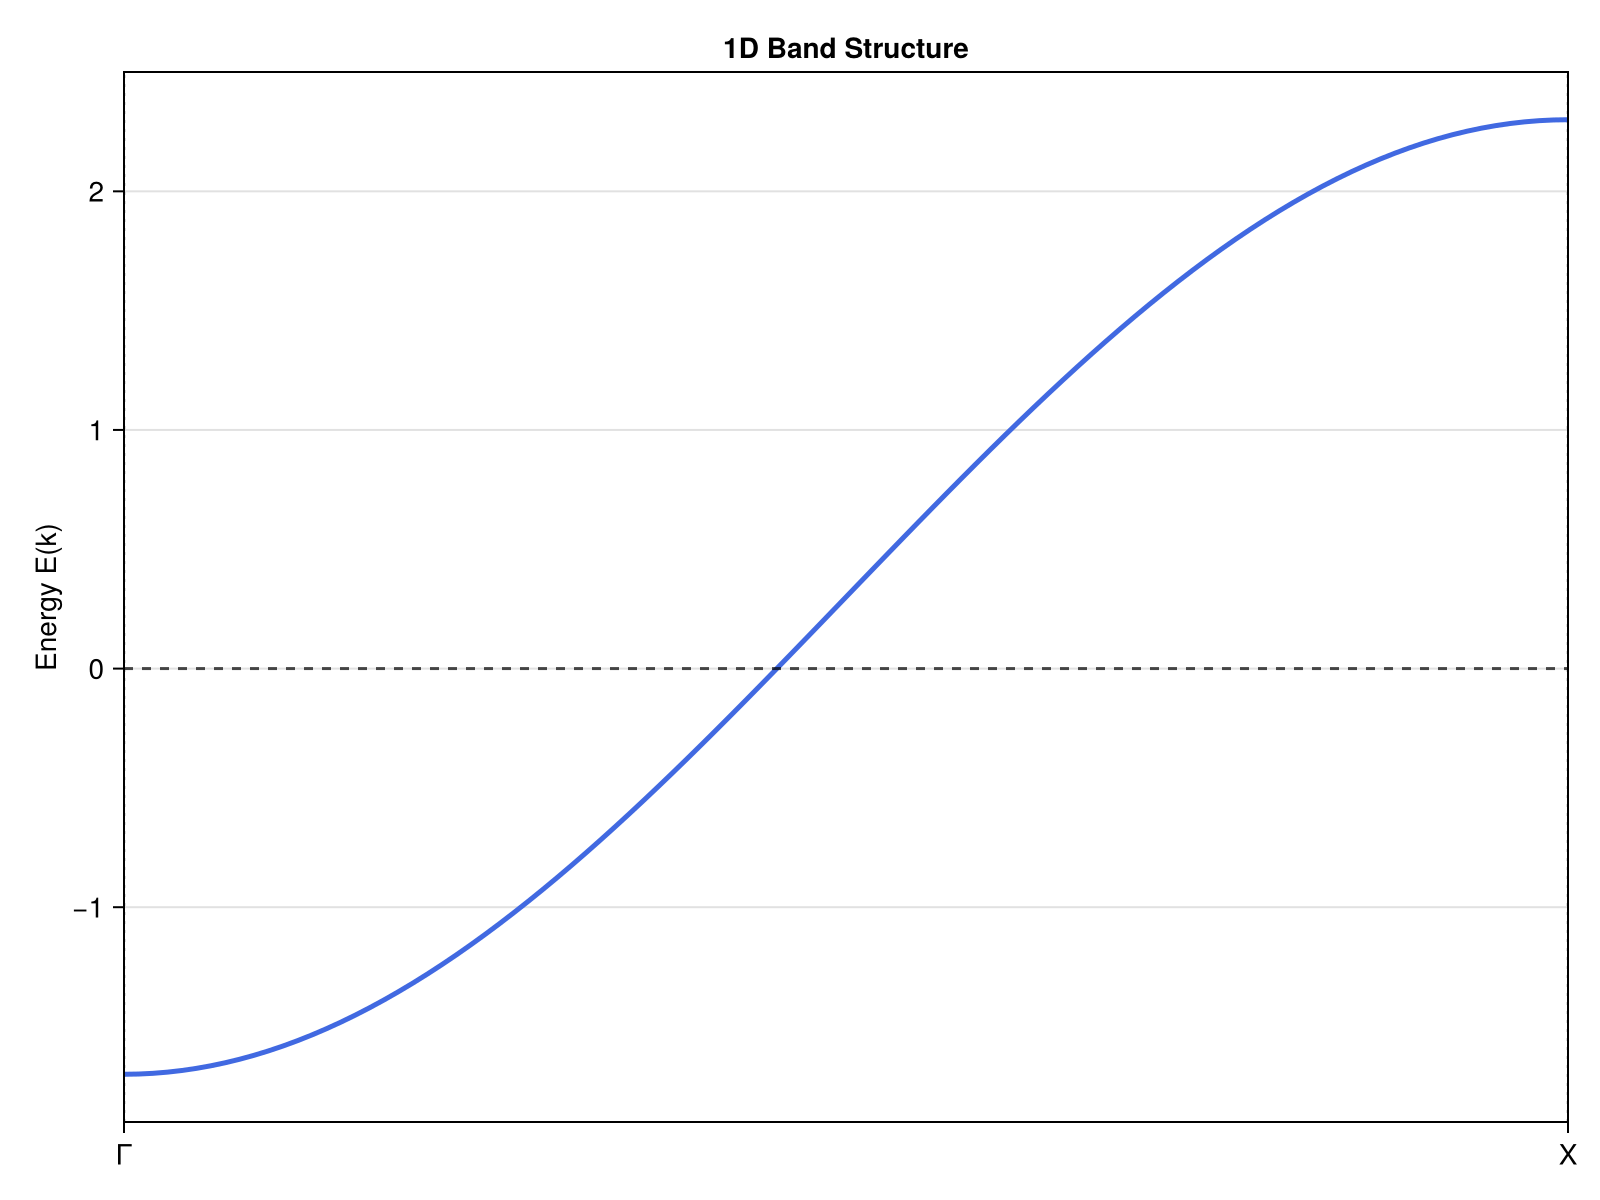

In [5]:
band_data = compute_band_data(params.model, generate_kpath(params.geometry; n_pts_per_segment=100))
f = plot(band_data)
save("tb_1d_eband.png", f)
f


In [8]:
print(TO)

────────────────────────────────────────────────────────────────────
                           Time                    Allocations      
                  ───────────────────────   ────────────────────────
Tot / % measured:      70.7s /   0.0%           3.54GiB /   0.0%    

Section   ncalls     time    %tot     avg     alloc    %tot      avg
────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────

### BCS reduced Hamiltonian


┌ Info: Compute phase transition data started
│   stage = "Compute phase transition data"
│   status = :start
└   context = (field = (type = "BCSReducedPairing",), model = (type = "TightBinding", dim = 1, n_hoppings = 1, EF = -0.3), interaction = (type = "ConstantInteraction",), kgrid = (type = "KGrid{1}", dim = 1, n_points = 200, weight_sum = 1.0000000000000002), approx = (type = "ExactTrLn",), n_phis = 100, n_temperatures = 10, warm_start = true)
Scanning Temperatures   0%|                             |  ETA: N/A
Scanning Temperatures  10%|██▉                          |  ETA: 0:00:02
Scanning Temperatures  20%|█████▊                       |  ETA: 0:00:02
Scanning Temperatures  30%|████████▊                    |  ETA: 0:00:01
Scanning Temperatures  40%|███████████▋                 |  ETA: 0:00:01
Scanning Temperatures  50%|██████████████▌              |  ETA: 0:00:01
Scanning Temperatures  60%|█████████████████▍           |  ETA: 0:00:00
Scanning Temperatures  70%|████████████████████

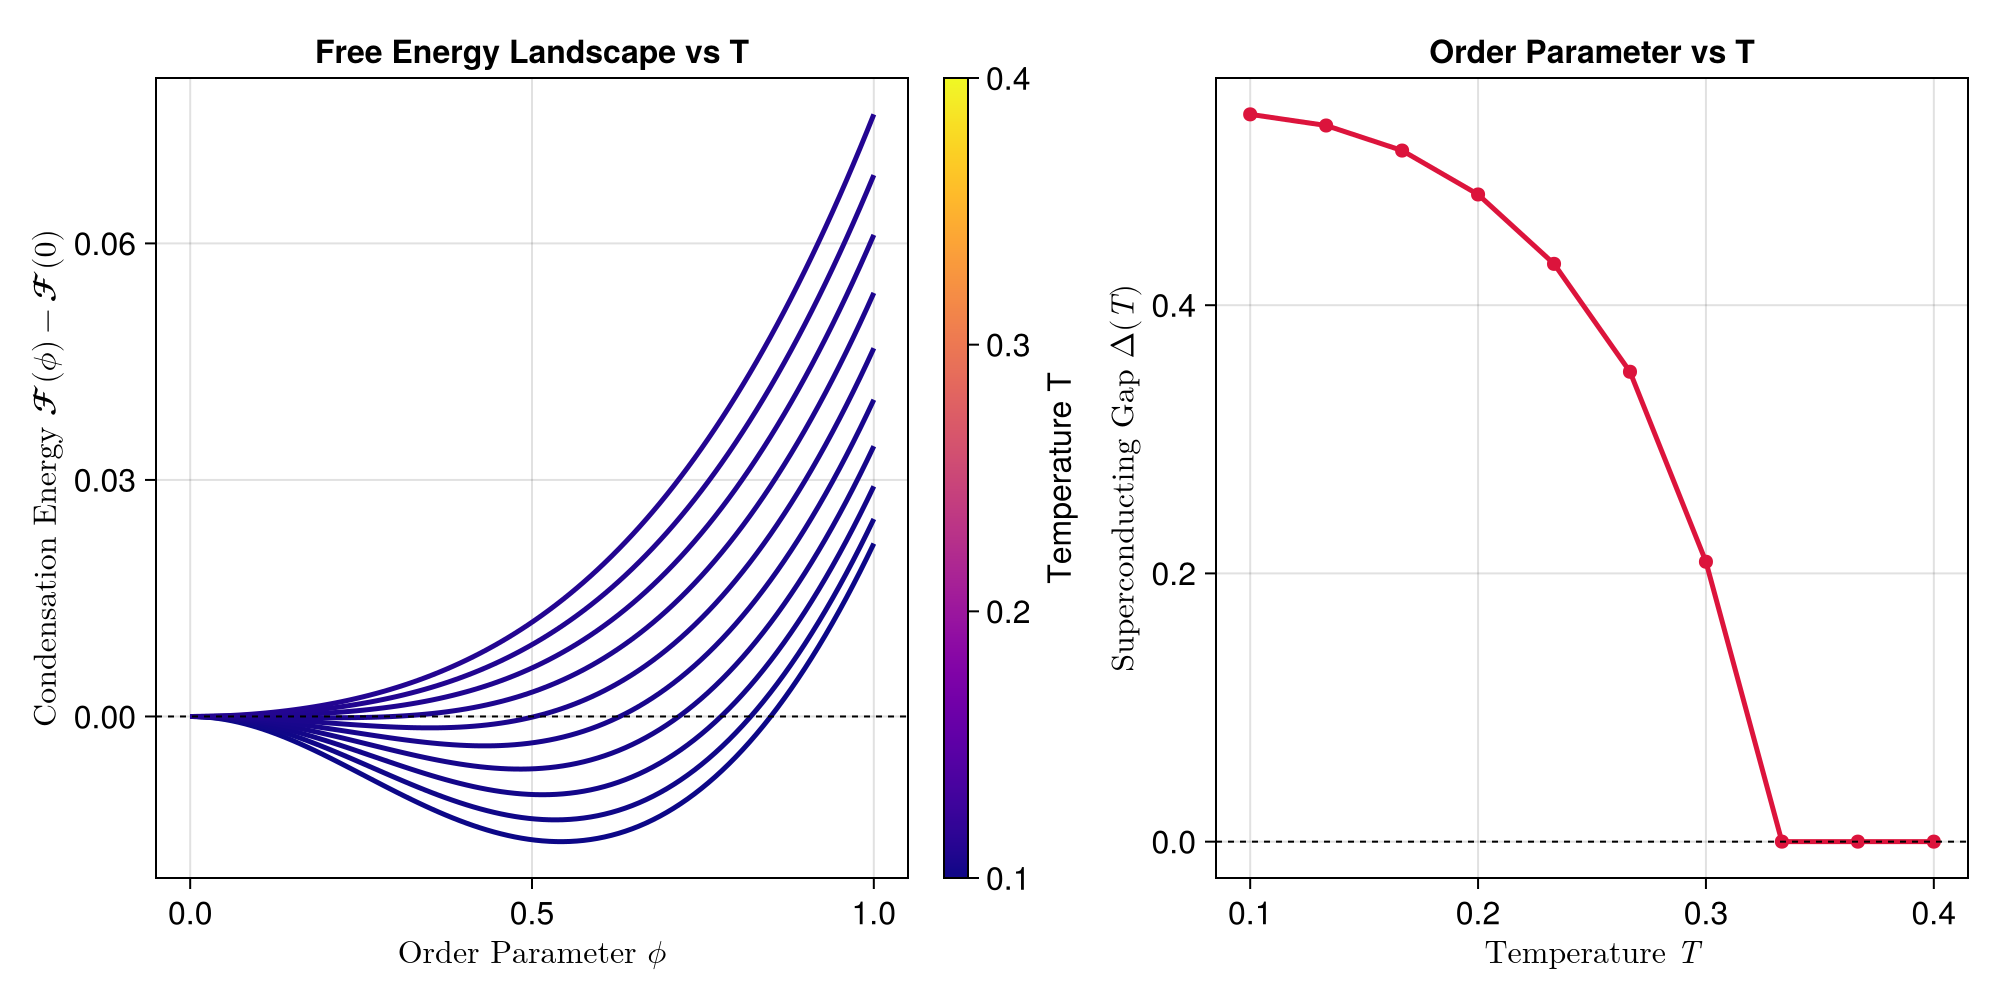

In [13]:
phase_data = res = compute_phase_transition_data(
    params.model,
    params.interaction,
    params.field,
    params.kpoints;
    params.task...
)
plot(phase_data)


In [15]:
band_data = compute_renormalized_band_data(
    params.model,
    params.interaction,
    params.field,
    params.kpoints,
    kpath,
    params.task.Ts
    )
plot(band_data)


LoadError: MethodError: no method matching compute_renormalized_band_data(::TightBinding{…}, ::ConstantInteraction, ::BCSReducedPairing, ::KGrid{…}, ::Brillouin.KPaths.KPathInterpolant{…}, ::Vector{…})
The function `compute_renormalized_band_data` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  compute_renormalized_band_data(::ElectronicDispersion, ::Interaction, ::AuxiliaryField, ::AbstractKGrid; kpath, Ts, approx, phi_guess, warm_start)
[0m[90m   @[39m [36mEliashberg[39m [90m~/Developer/theory/Eliashberg/src/Solvers/[39m[90m[4mspectra.jl:275[24m[39m


In [ ]:
T_val = 0.1
collective_data = compute_collective_mode_spectral_data(T_val, sc_field, tb,  params.interaction, params.kgrid, kpath; eta=0.015)
plot(collective_data)


### FFLO Pairing

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

# 设定环境参数
T_val = 0.01
h_val = 0.5 # 施加一个 Zeeman 磁场 (注意：h 必须小于裸能隙，但在 Pauli 极限附近)

# 2. 设定我们要扫描的 q 范围 (沿着 qx 方向)
q_vals = range(0.0, 1.0, length=300) # 扫描 0 到 1.0 的动量

zeeman_data = compute_zeeman_pairing_data(T_val, h_val, q_vals, tb, interaction, kgrid)
plot_zeeman_pairing_landscape(q_vals, zeeman_data.condensation_energy, zeeman_data.optimal_gaps; minimum_index=zeeman_data.minimum_index)

## 2D Tight-Binding model


### BCS reduced Hamiltonian

In [3]:

lattice = SquareLattice(1.5)
tb = TightBinding(lattice, 1.0, 0.0)

kgrid = generate_reciprocal_lattice(lattice, 50, 50)

path = generate_kpath(lattice; n_pts_per_segment=50)

KPath{2}(StaticArraysCore.SVector{2, Float64}[[0.0, 0.0], [0.041887902047863905, 0.0], [0.08377580409572781, 0.0], [0.1256637061435917, 0.0], [0.16755160819145562, 0.0], [0.20943951023931953, 0.0], [0.2513274122871834, 0.0], [0.2932153143350474, 0.0], [0.33510321638291124, 0.0], [0.37699111843077515, 0.0]  …  [0.37699111843077526, 0.37699111843077526], [0.3351032163829113, 0.3351032163829113], [0.29321531433504733, 0.29321531433504733], [0.25132741228718336, 0.25132741228718336], [0.2094395102393194, 0.2094395102393194], [0.16755160819145565, 0.16755160819145565], [0.1256637061435919, 0.1256637061435919], [0.08377580409572793, 0.08377580409572793], [0.04188790204786397, 0.04188790204786397], [0.0, 0.0]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 51, 101, 151], ["Γ", "X", "M", "Γ"])

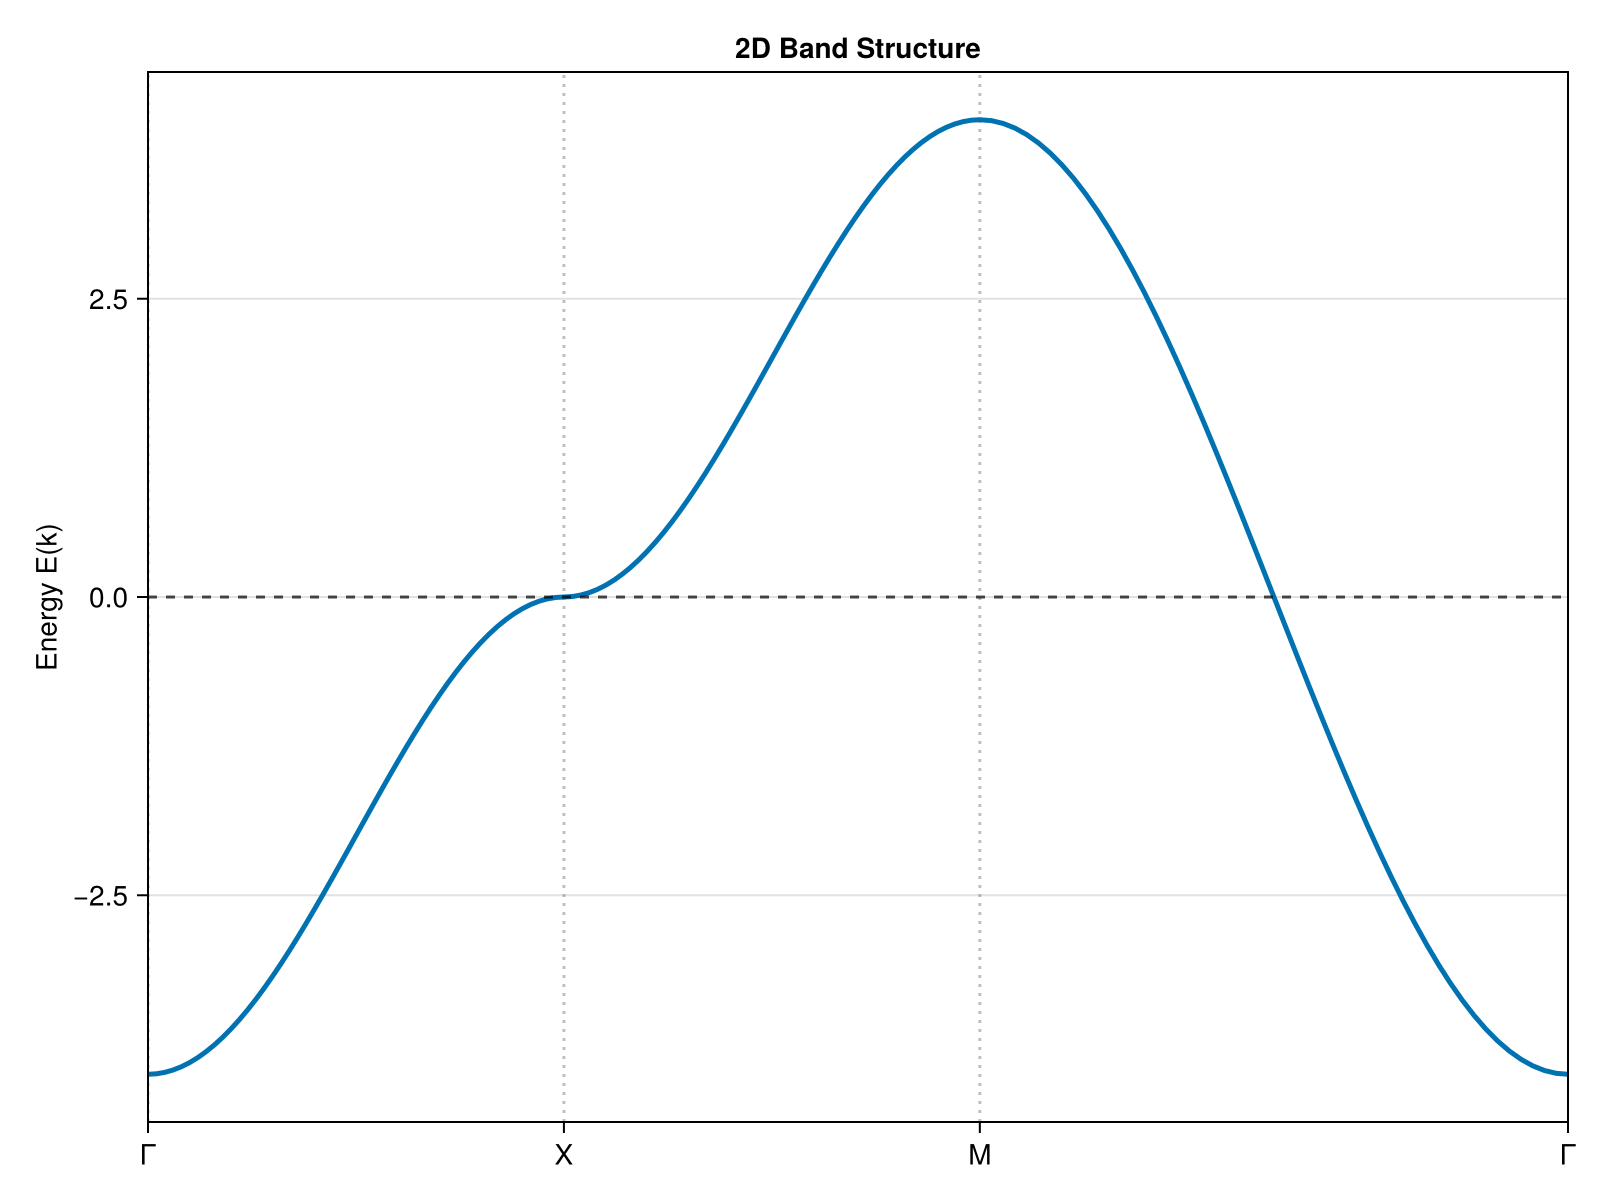

In [5]:
band_data = compute_band_data(tb, path)
plot(band_data)


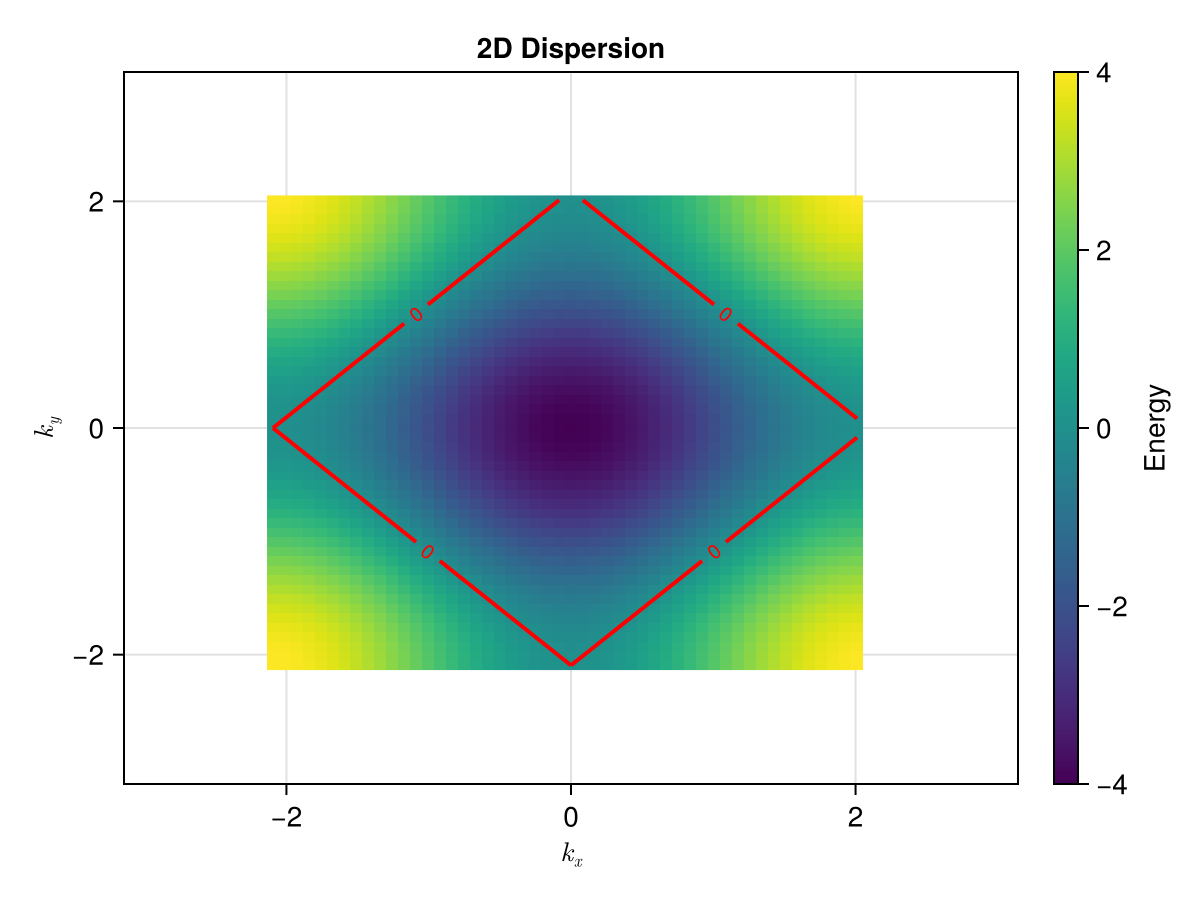

In [6]:
dispersion_data = compute_dispersion_surface_data(tb, kgrid)
f = plot_dispersion_surface(dispersion_data.kxs, dispersion_data.kys, dispersion_data.energy_matrix)
save("tb_2d_eband.png", f)
f


#### s-wave

In [6]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:s_wave)

Ts = range(0.1, 0.4, length=10)   # 温度扫描范围 (从极低温到超过 Tc)



0.1:0.03333333333333333:0.4

In [8]:
k_node = (π/2, π/2)
bcs_model = MeanFieldDispersion(tb, sc_field, 0.15)
H_node = ε(k_node, bcs_model)

2×2 Hermitian{Float64, StaticArraysCore.SMatrix{2, 2, Float64, 4}} with indices SOneTo(2)×SOneTo(2):
 2.82843   0.15
 0.15     -2.82843

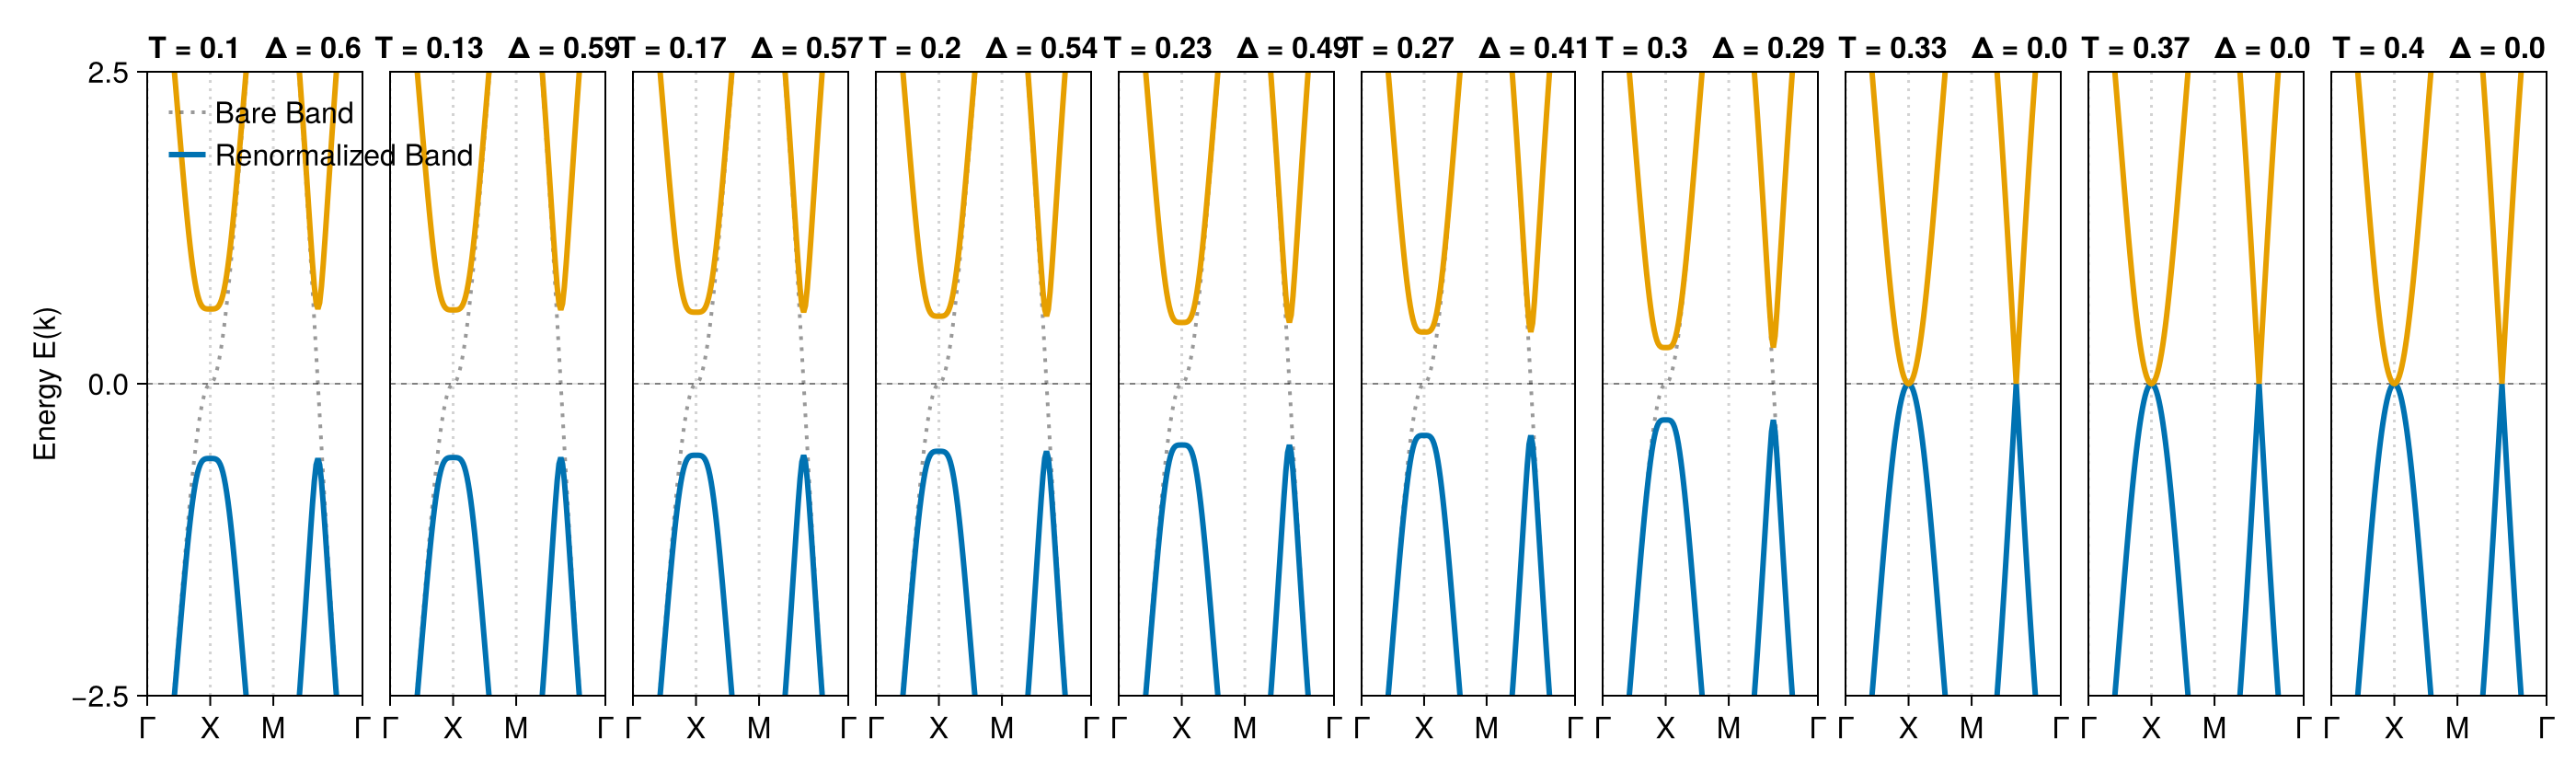

In [10]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)

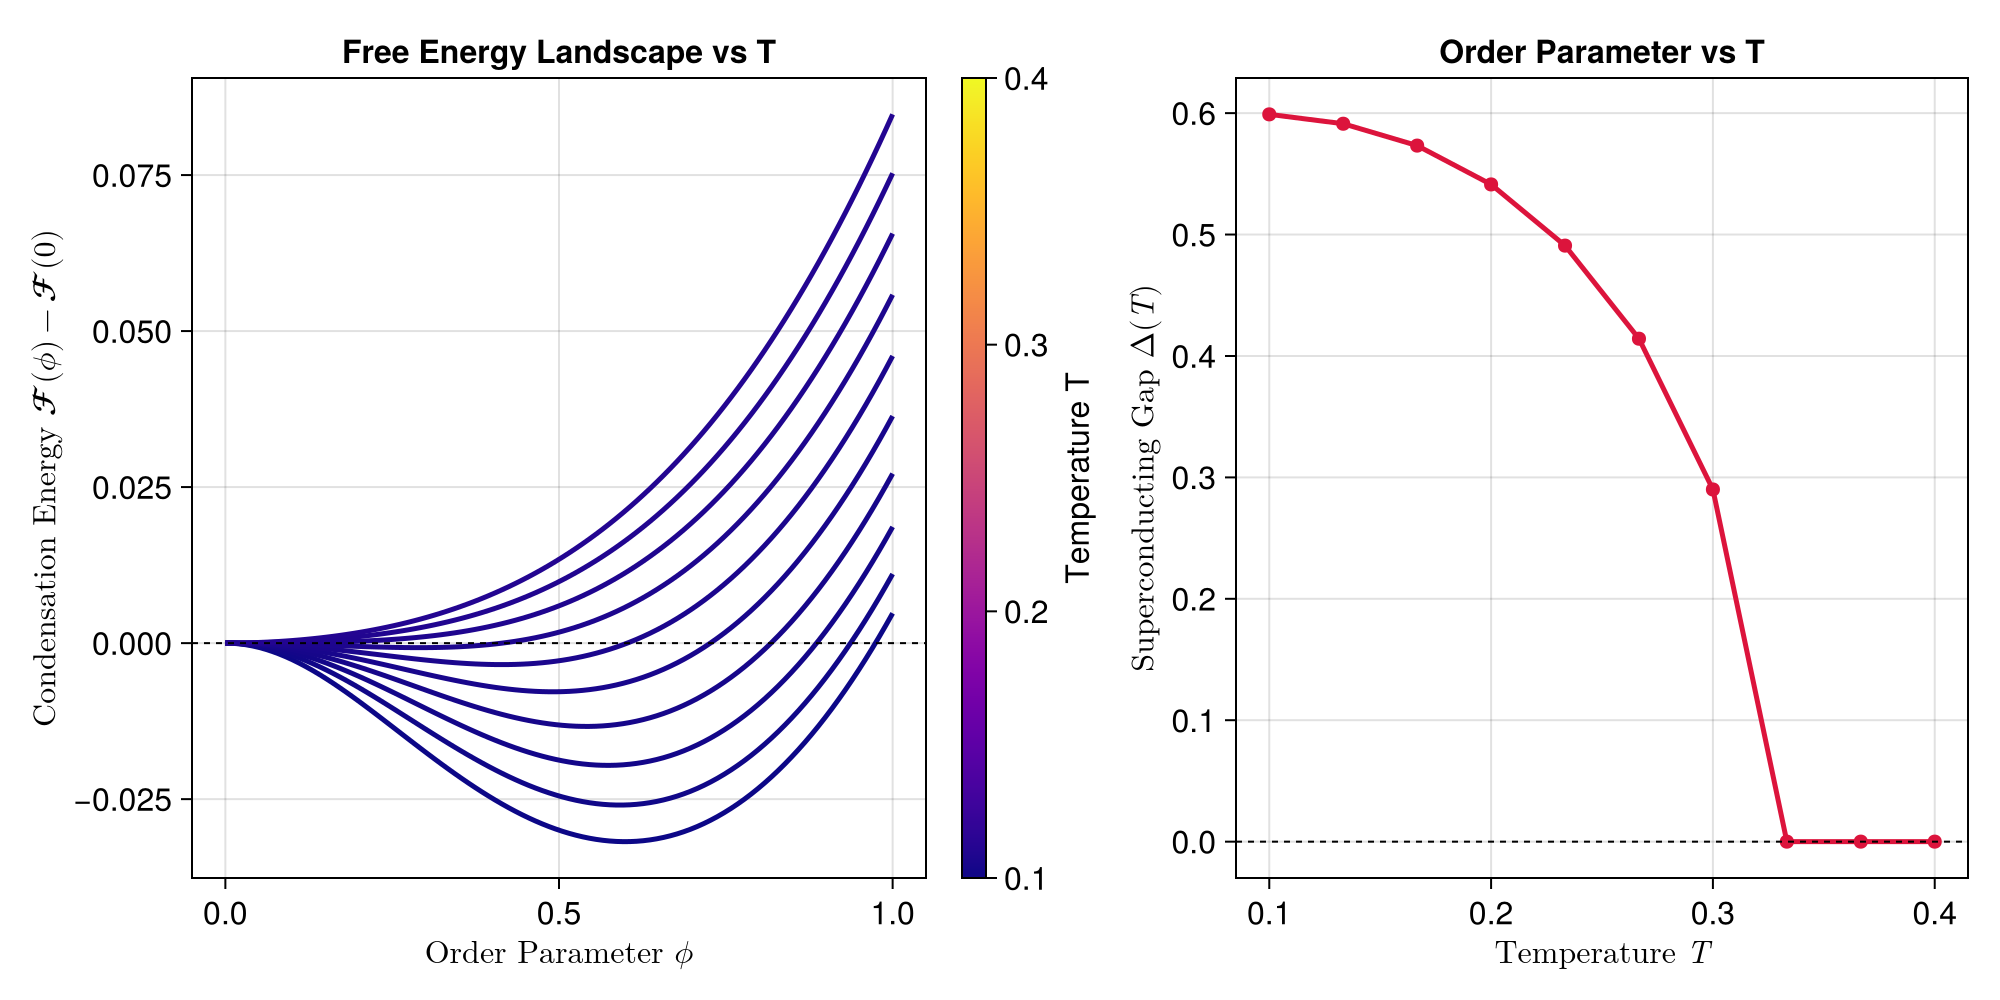

In [11]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


#### $s_{\pm}$ wave

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-5)

sc_field = BCSReducedPairing(:s_plus_minus_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.4, length=10)   # 温度扫描范围 (从极低温到超过 Tc)

In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)


#### p-wave

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:p_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.5, length=10)   # 温度扫描范围 (从极低温到超过 Tc)


In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)


#### d-wave

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-3.5)

sc_field = BCSReducedPairing(:d_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.5, length=10)   # 温度扫描范围 (从极低温到超过 Tc)

In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)


### Competition with CDW

### Competition with SDW

In [8]:
tb_spinor = SpinorDispersion(tb)
interaction_U = ConstantInteraction(2.5) # 这里可以换成你更复杂的库仑/吸引相互作用

# 2. 定义你想让它们竞争的两个场 (这里强烈建议先 SDW，后 BCS)
sdw_field = SpinDensityWave((π, π), :z)

# 3. 🌟 终极合体：构造 CompositeField
coex_field = CompositeField(sdw_field, sc_field)

CompositeField{Tuple{SpinDensityWave{2, :z}, BCSReducedPairing}}((SpinDensityWave{2, :z}([3.141592653589793, 3.141592653589793]), BCSReducedPairing(:s_wave)))

In [9]:
Ts = range(0.01, 0.1, length=10)

0.01:0.01:0.1

In [12]:
k_node = (π/2, π/2)
coex_model = MeanFieldDispersion(tb, coex_field)
H_node = ε(k_node, coex_model)

LoadError: MethodError: no method matching MeanFieldDispersion(::TightBinding{2}, ::CompositeField{Tuple{SpinDensityWave{2, :z}, BCSReducedPairing}})
The type `MeanFieldDispersion` exists, but no method is defined for this combination of argument types when trying to construct it.

[0mClosest candidates are:
[0m  MeanFieldDispersion(::M, ::F, [91m::Float64[39m) where {D, M<:ElectronicDispersion{D}, F<:AuxiliaryField}
[0m[90m   @[39m [35mEliashberg[39m [90m~/Developer/theory/Eliashberg/src/Responses/[39m[90m[4mmean_field.jl:6[24m[39m
[0m  MeanFieldDispersion(::M, ::F, [91m::Real[39m) where {D, M<:ElectronicDispersion{D}, F<:AuxiliaryField}
[0m[90m   @[39m [35mEliashberg[39m [90m~/Developer/theory/Eliashberg/src/Responses/[39m[90m[4mmean_field.jl:31[24m[39m
[0m  MeanFieldDispersion(::ElectronicDispersion, ::CompositeField, [91m::AbstractVector{<:Real}[39m)
[0m[90m   @[39m [35mEliashberg[39m [90m~/Developer/theory/Eliashberg/src/Responses/[39m[90m[

In [10]:
guesses = [0.3, 0.1]

band_data = compute_renormalized_band_data(
    Ts, 
    coex_field,     # 传入复合场
    tb_spinor, 
    interaction_U, 
    kgrid, 
    path; 
    phi_guess=guesses # 传入向量初猜
)

RenormalizedBandData{2, Matrix{Float64}}(KPath{2}(StaticArraysCore.SVector{2, Float64}[[0.0, 0.0], [0.041887902047863905, 0.0], [0.08377580409572781, 0.0], [0.1256637061435917, 0.0], [0.16755160819145562, 0.0], [0.20943951023931953, 0.0], [0.2513274122871834, 0.0], [0.2932153143350474, 0.0], [0.33510321638291124, 0.0], [0.37699111843077515, 0.0]  …  [0.37699111843077526, 0.37699111843077526], [0.3351032163829113, 0.3351032163829113], [0.29321531433504733, 0.29321531433504733], [0.25132741228718336, 0.25132741228718336], [0.2094395102393194, 0.2094395102393194], [0.16755160819145565, 0.16755160819145565], [0.1256637061435919, 0.1256637061435919], [0.08377580409572793, 0.08377580409572793], [0.04188790204786397, 0.04188790204786397], [0.0, 0.0]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 51, 101, 151], ["Γ", "X", "M", "Γ"]), [-4.0 -4.0; -3.996053456856543 -3.996053456856543; … ; -3.9921069137130862 -3.9921069137130862; -4

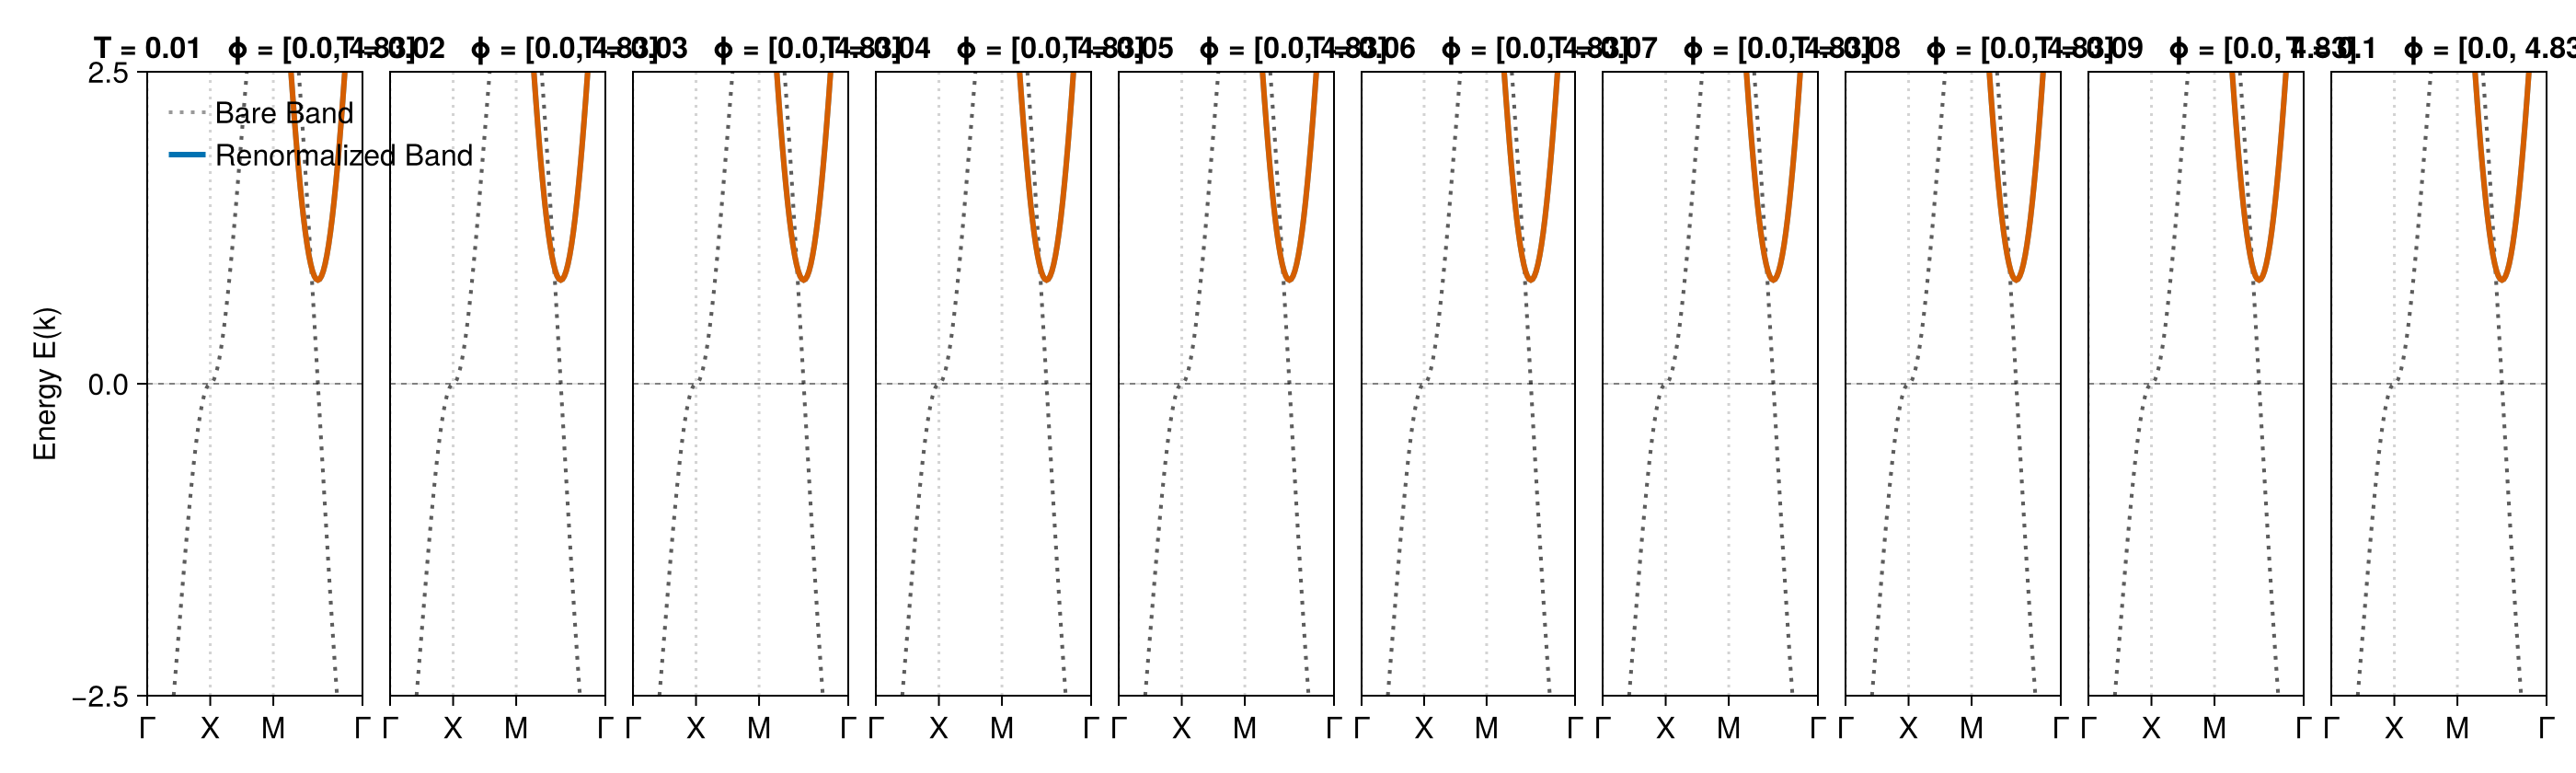

In [11]:
plot(band_data)

## 3D Tight-Binding model

In [ ]:
lattice = CubicLattice(1.5)
tb = TightBinding(lattice, 1.0, 0.0)

kgrid = generate_reciprocal_lattice(lattice, 20, 20, 20)

path = generate_kpath(lattice; n_pts_per_segment=20)



In [ ]:
band_data = compute_band_data(tb, path)
f = plot(band_data)
save("tb_3d_eband_GXMGR.png", f)
f


In [ ]:
# fermi_surface = compute_fermi_surface_volume(tb; n_pts=60)
# f = plot_fermi_surface(fermi_surface.kxs, fermi_surface.kys, fermi_surface.kzs, fermi_surface.energy_volume; E_Fermi=0.0)
# save("tb_3d_eband_fs.png", f)


In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:s_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.4, length=10)   # 温度扫描范围 (从极低温到超过 Tc)


In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)
